<h1>2: Sales Analysis</h1>

In [57]:
import pandas as pd
df = pd.read_csv("sales_large.csv")
df

,OrderID,Product,Category,Sales,Quantity,Region
0,1,Laptop,Electronics,54930,3,North
1,2,Monitor,Furniture,37981,8,North
2,3,Chair,Electronics,74298,2,North
3,4,Monitor,Electronics,51167,9,South
4,5,Chair,Electronics,80304,3,South
...,...,...,...,...,...,...
295,296,Laptop,Electronics,88360,5,West
296,297,Mobile,Furniture,13927,7,North
297,298,Table,Furniture,98680,8,North
298,299,Mobile,Electronics,27443,7,West


<h1>Section A: Data Exploration</h1>

In [58]:
# Q1 Load the dataset and display:
#First 5 rows
#Last 5 rows 
print(df.head(5))
df.tail(5)

   OrderID  Product     Category  Sales  Quantity Region
0        1   Laptop  Electronics  54930         3  North
1        2  Monitor    Furniture  37981         8  North
2        3    Chair  Electronics  74298         2  North
3        4  Monitor  Electronics  51167         9  South
4        5    Chair  Electronics  80304         3  South


,OrderID,Product,Category,Sales,Quantity,Region
295,296,Laptop,Electronics,88360,5,West
296,297,Mobile,Furniture,13927,7,North
297,298,Table,Furniture,98680,8,North
298,299,Mobile,Electronics,27443,7,West
299,300,Laptop,Furniture,84973,5,West


In [82]:
#Q2 Find:
#Total rows
#Total columns
#Column names 

df.shape
df.shape[0]
df.shape[1] 
df.columns.tolist()

(300, 6)


['OrderID', 'Product', 'Category', 'Sales', 'Quantity', 'Region']

In [60]:
#Q3
#Check:
#Data types
#Missing values
#Duplicate records 
df.dtypes
df.isnull().sum()
df.duplicated().sum()

np.int64(0)

<h1>Section B: Data Analysis</h1>

In [61]:
#Q4 Calculate:

#Total Sales
#Average Sales
#Maximum Sales
#Minimum Sales 

df.describe() 
df["Sales"].agg(["sum", "mean", "max", "min"])

sum     1.571959e+07
mean    5.239864e+04
max     9.979500e+04
min     5.281000e+03
Name: Sales, dtype: float64

In [62]:
#Q5 Find:
#Total Quantity Sold
#Average Quantity Sold 

df["Quantity"].sum()
df["Quantity"].mean()

np.float64(4.983333333333333)

In [63]:
#Q6 Find Top 10 orders by sales amount. 
#pehle sort karlo phir top 10 .head() ka use karo 

sort = df.sort_values(by="Sales", ascending=False).head(10)
print(sort) 

     OrderID Product     Category  Sales  Quantity Region
248      249   Chair    Furniture  99795         7   East
144      145   Table    Furniture  99588         2  South
91        92   Chair    Furniture  99242         3  North
297      298   Table    Furniture  98680         8  North
181      182   Chair  Electronics  97464         4  South
79        80  Mobile    Furniture  97447         7  North
180      181  Mobile  Electronics  97324         2   East
151      152  Laptop  Electronics  97152         9   East
277      278  Laptop  Electronics  96749         4   West
286      287  Mobile    Furniture  96736         7  South


<h1>Section C: GroupBy Analysis</h1>

In [64]:
# Q7 Find Region-wise:
#Total Sales
#Average Sales
#Total Quantity 

df.groupby("Region").agg({
    "Sales" : "sum",
    "Sales" : "mean",
    "Quantity" : "sum"
})

,Sales,Quantity
Region,,
East,49992.600000,325
North,49898.397590,430
South,57523.092308,331
West,52752.919540,409


In [65]:
#Q8 Find Product-wise:
#Total Sales
#Average Sales 

df.groupby("Product").agg({
    "Sales" : "sum",
    "Sales" : "mean"
}) 


,Sales
Product,
Chair,55321.516667
Laptop,50595.846154
Mobile,53226.257576
Monitor,48866.825397
Table,54783.195652


In [66]:
#Q9 Find Category-wise:

#Total Sales
#Total Quantity 

df.groupby("Category").agg({
    "Sales": "sum",
    "Quantity": "sum"
})

,Sales,Quantity
Category,,
Electronics,7691164,739
Furniture,8028427,756


In [67]:
# Q10 Identify:

#Highest Revenue Region # Revenue=Sales
#Highest Revenue Product
#Highest Revenue Category 

df.groupby("Sales")["Region"].sum().idxmax()
df.groupby("Sales")["Product"].sum().idxmax()
df.groupby("Sales")["Category"].sum().idxmax()

np.int64(54153)

<h1>Section D: NumPy Questions</h1>


In [68]:
# Q11 Find number of orders where:
#Sales > 50000  
#correct h ye !!!!
import numpy as np

count = np.sum(df["Sales"] > 50000)
print(count)

156


In [69]:
# Find percentage of orders where:
#Quantity > 5 
#correct h ye !!!!
import numpy as np 

percentage = (np.sum(df["Quantity"] > 5) / len(df)) * 100
print(percentage)


43.333333333333336


<h1>Section E: Visualization</h1>

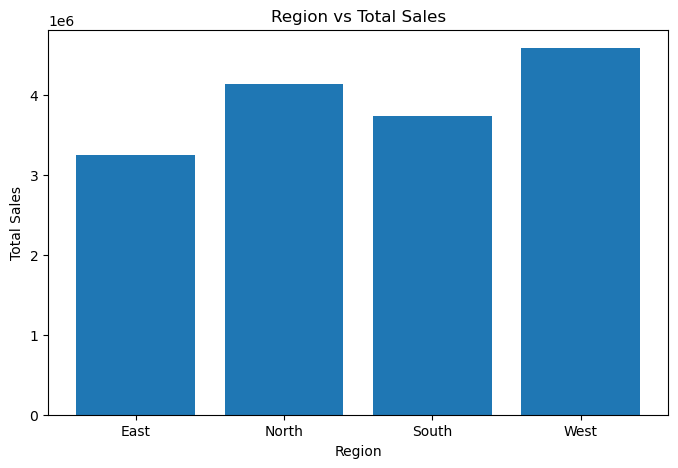

In [70]:
# Bar Chart
# Region vs Total Sales 

import matplotlib.pyplot as plt
import pandas as pd

region_sales = df.groupby("Region")["Sales"].sum()

plt.figure(figsize=(8,5))
plt.bar(region_sales.index, region_sales.values)

plt.title("Region vs Total Sales")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.show()




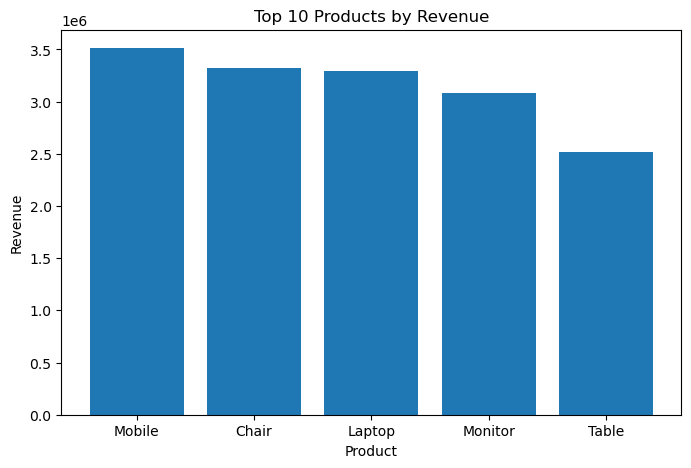

In [77]:
# Chart 2 Bar Chart
#Top 10 Products by Revenue 

import matplotlib.pyplot as plt
import pandas as pd 

top_10_products = df.groupby("Product")["Sales"].sum().nlargest(10)
#df.groupby("Product")["Sales"].sum().head(10) 
plt.figure(figsize=(8,5))
plt.bar(top_10_products.index, top_10_products.values)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue") 

plt.show() 


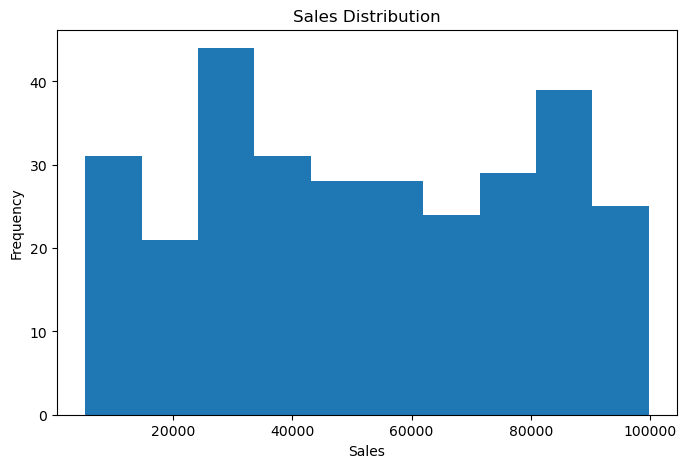

In [78]:
# Chart 3 Histogram
#Sales Distribution 

import matplotlib.pyplot as plt
import pandas as pd 

plt.figure(figsize=(8,5))
plt.hist(df["Sales"], bins=10)

plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

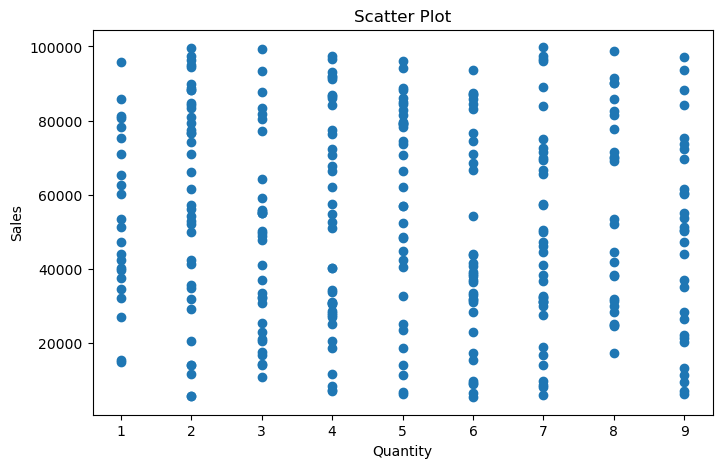

In [85]:
# Chart 4
#Scatter Plot
#Quantity vs Sales 

import matplotlib.pyplot as plt
import pandas as pd 

# Load data (file name apna daalna)


plt.figure(figsize=(8,5))

plt.scatter(df["Quantity"], df["Sales"])

plt.title("Scatter Plot")
plt.xlabel("Quantity")
plt.ylabel("Sales")

plt.show()
